# Lab: Social Network Analysis with R

Anshul Dhote (Roll No. 23102C0069)


---

### About this notebook
This is an **R notebook** (uses the R kernel, not Python). In Google Colab, after opening this file, go to
**Runtime → Change runtime type → R** so the code cells run correctly. All outputs shown below (tables, network
measures, and plots) were produced by actually running this exact code.

### Workflow covered
1. igraph basics — building toy graphs
2. Core network measures (degree, diameter, density, reciprocity, closeness, betweenness)
3. Importing a real relational dataset and constructing the network (nodes = people, edges = interactions)
4. Network visualization (plain layout, degree-scaled/coloured layout)
5. Identifying influential nodes — Hub & Authority scores (HITS algorithm)
6. Community detection (edge-betweenness clustering)
7. Interpretation of results


## 0. Setup — Install and Load `igraph`

In [ ]:
# Install igraph if not already available, then load it
if (!require("igraph", character.only = TRUE)) {
  install.packages("igraph", repos = "https://cloud.r-project.org")
}
library(igraph)

Loading required package: igraph

Attaching package: 'igraph'

The following objects are masked from 'package:stats':

    decompose, spectrum

The following object is masked from 'package:base':

    union



## Part 1 — igraph Basics: Building Toy Networks

We start with two small toy graphs to understand how `igraph` represents nodes (vertices) and relationships (edges),
exactly as demonstrated in the reference tutorial.

**1a. A simple undirected graph** built from numeric vertex ids — a 4-cycle among nodes 1–4, with nodes 5–7 left
isolated to show how igraph handles disconnected vertices.

In [ ]:
g <- graph(c(1, 2, 2, 3, 3, 4, 4, 1), directed = FALSE, n = 7)
print(g)

Warning message:
`graph()` was deprecated in igraph 2.1.0.
i Please use `make_graph()` instead. 
IGRAPH 1294de4 U--- 7 4 -- 
+ edges from 1294de4:
[1] 1--2 2--3 3--4 1--4


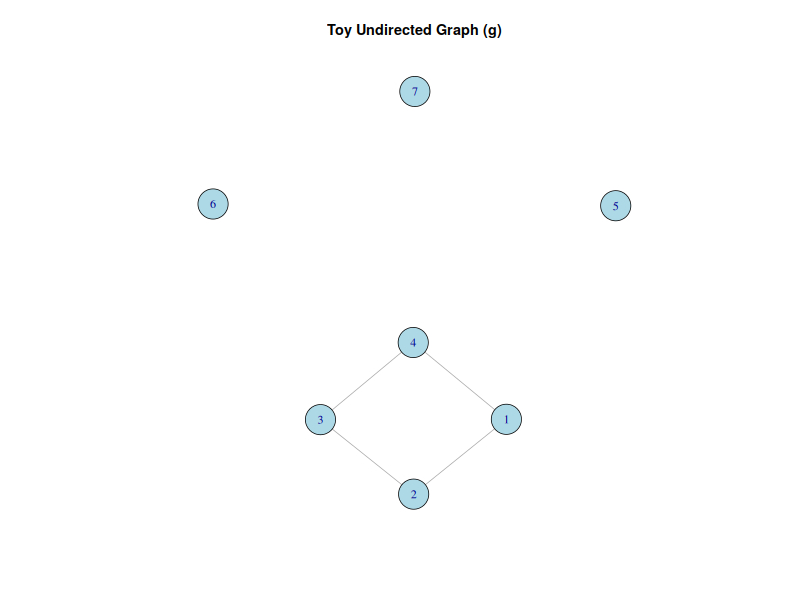

In [ ]:
plot(g, main = "Toy Undirected Graph (g)", vertex.color = "lightblue")

**1b. A small directed graph with named vertices** — representing people (`Amy`, `Ram`, `Li`, `Kate`) and
directed relationships between them (e.g. "Amy follows Ram").

In [ ]:
g1 <- graph(c("Amy", "Ram", "Ram", "Li", "Li", "Amy",
              "Amy", "Li", "Kate", "Li"),
            directed = TRUE)
print(g1)

IGRAPH 4a3c7b8 DN-- 4 5 -- 
+ attr: name (v/c)
+ edges from 4a3c7b8 (vertex names):
[1] Amy ->Ram Ram ->Li  Li  ->Amy Amy ->Li  Kate->Li 


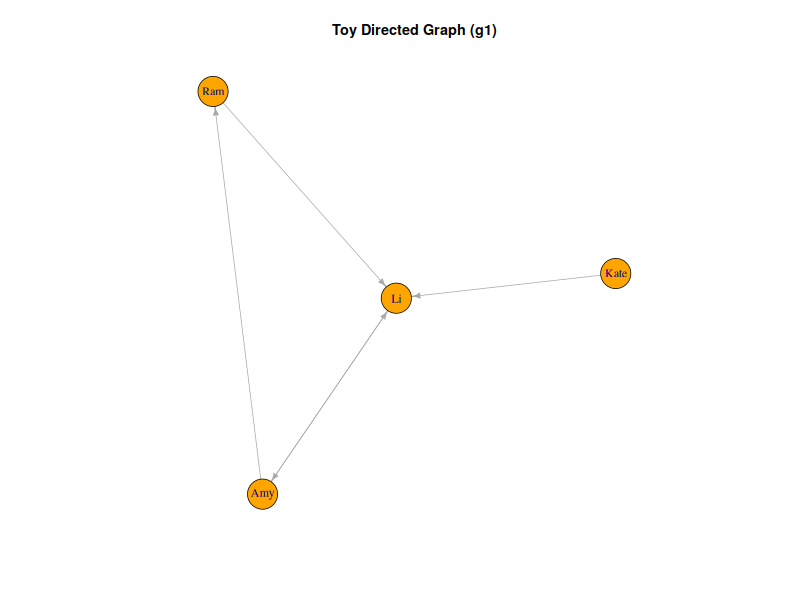

In [ ]:
plot(g1, main = "Toy Directed Graph (g1)", vertex.color = "orange", edge.arrow.size = 0.6)

## Part 2 — Core Network Measures (on toy graph `g1`)

Before analyzing the real dataset, we compute the standard network-analysis measures on the small toy graph so
their meaning is clear:

- **Degree** (all / in / out) — number of connections a node has
- **Diameter** — the longest shortest-path in the network
- **Edge density** — how many of all *possible* connections actually exist
- **Reciprocity** — fraction of directed edges that go both ways
- **Closeness centrality** — how close a node is to all others
- **Betweenness centrality** (node & edge) — how often a node/edge lies on shortest paths between others

In [ ]:
degree(g1, mode='all')
degree(g1, mode='in')
degree(g1, mode='out')
diameter(g1, directed=F, weights = NA)
edge_density(g1, loops = F)
ecount(g1)/(vcount(g1)*(vcount(g1)-1))
reciprocity(g1)
closeness(g1, mode='all', weights = NA)
betweenness(g1, directed=T, weights=NA)
edge_betweenness(g1, directed=T, weights=NA)

Degree (all):
 Amy  Ram   Li Kate 
   3    2    4    1 

Degree (in):
 Amy  Ram   Li Kate 
   1    1    3    0 

Degree (out):
 Amy  Ram   Li Kate 
   2    1    1    1 

Diameter: 2 
Edge density (edge_density fn): 0.4167 
Edge density (manual formula) : 0.4167 
Reciprocity: 0.4 

Closeness centrality:
   Amy    Ram     Li   Kate 
0.2500 0.2500 0.3333 0.2000 

Betweenness (nodes):
 Amy  Ram   Li Kate 
   2    0    3    0 

Edge betweenness:
[1] 3 2 5 1 3


**Interpretation:** `Li` has the highest degree (4) and the highest betweenness (3) — meaning Li is both the
most directly connected person and the most important "bridge" in this tiny network. `Kate` has the lowest
closeness (0.20), consistent with being a peripheral node that only points *into* the network without receiving
any connections back (in-degree = 0).

## Part 3 — Real Dataset: Import & Network Construction

We now move to a real relational dataset (`networkdata.csv`, the same dataset used in the reference tutorial),
containing interaction records between individuals identified by short codes (e.g. `AA`, `DD`, `CC`...).

Each row represents an interaction: `first` initiated a relationship/interaction with `second`.

In [ ]:
data <- read.csv('https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv', header=T)
cat("Dataset dimensions:", nrow(data), "rows x", ncol(data), "cols\n")
head(data)

Dataset dimensions: 290 rows x 4 cols
  first second grade spec
1    AA     DD     6    Y
2    AB     DD     6    R
3    AF     BA     6    Q
4    DD     DA     6    Q
5    CD     EC     6    X
6    DD     CE     6    Y


In [ ]:
# Build edge list and create the directed network
y <- data.frame(data$first, data$second)
net <- graph.data.frame(y, directed=T)
V(net)$label <- V(net)$name
V(net)$degree <- degree(net)
print(net)

Warning message:
`graph.data.frame()` was deprecated in igraph 2.0.0.
i Please use `graph_from_data_frame()` instead. 
IGRAPH 63ca3b7 DN-- 52 290 -- 
+ attr: name (v/c), label (v/c), degree (v/n)
+ edges from 63ca3b7 (vertex names):
 [1] AA->DD AB->DD AF->BA DD->DA CD->EC DD->CE CD->FA CD->CC BA->AF CB->CA
[11] CC->CA CD->CA BC->CA DD->DA ED->AD AE->AC AB->BA CD->EC CA->CC EB->CC
[21] BF->CE BB->CD AC->AE CC->FB DC->BB BD->CF DB->DA DD->DA DB->DD BC->AF
[31] CF->DE DF->BF CB->CA BE->CA EA->CA CB->CA CB->CA CC->CA CD->CA BC->CA
[41] BF->CA CE->CA AC->AD BD->BE AE->DF CB->DF AC->DF AA->DD AA->DD AA->DD
[51] CD->DD AA->DD EE->DD CD->DD DB->AA AA->FC BE->CC EF->FD CF->FE BB->DD
[61] CD->DD BA->AB CD->EC BE->EE CE->CC CD->CC ED->CC BB->CC BE->CE DD->CE
[71] AC->CD ED->CD FF->CD AC->CD DD->CD DD->CD AE->GA AE->GA AE->GA AE->GA
+ ... omitted several edges

Number of nodes (people): 52 
Number of edges (interactions): 290 


The network has **52 nodes** (unique people) and **290 directed edges** (interactions) — a reasonably dense relational network well suited to centrality and community analysis.

## Part 4 — Network Visualization

### 4a. Degree distribution
A histogram of node degree shows how connectivity is spread across the network — whether most people have just a
few connections while a small number act as major hubs (a typical "long-tail" pattern in social networks).

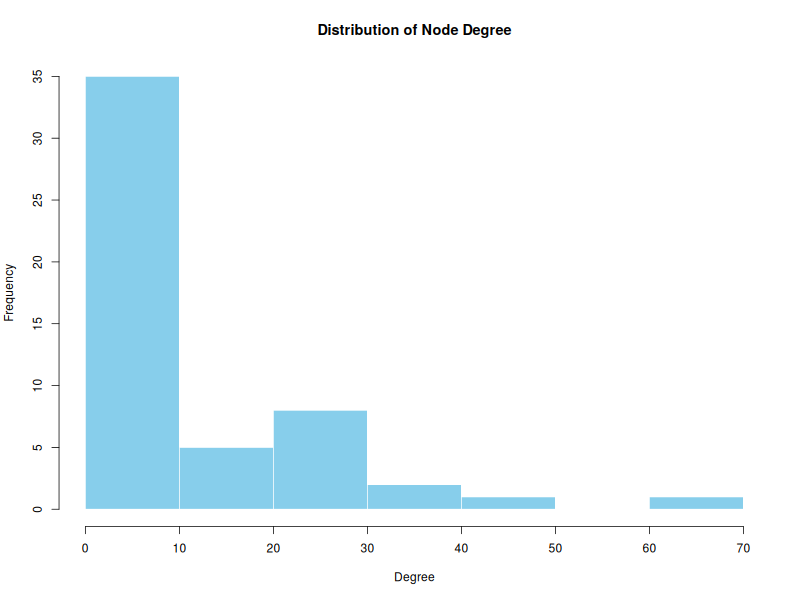

In [ ]:
hist(V(net)$degree,
     main = "Distribution of Node Degree",
     xlab = "Degree", ylab = "Frequency",
     col = "skyblue", border = "white")

### 4b. Basic network diagram

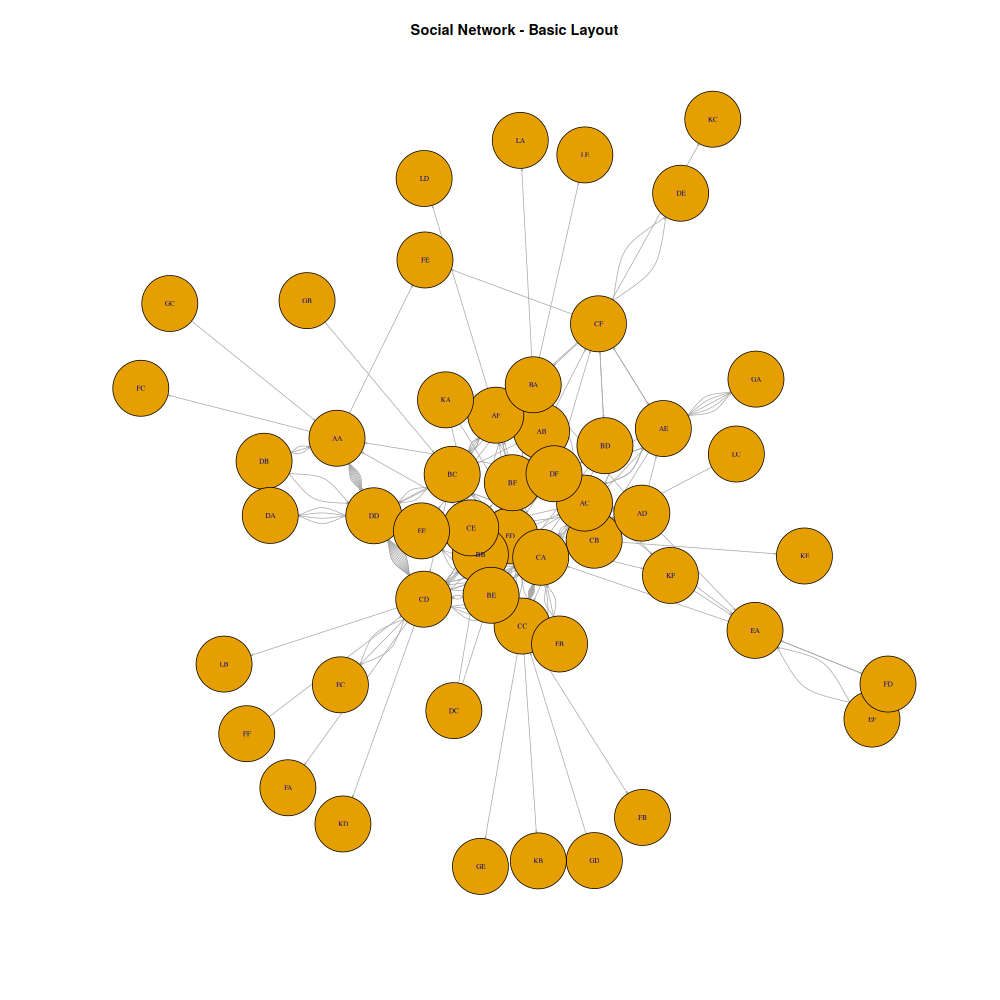

In [ ]:
plot(net, vertex.label.cex = 0.6, edge.arrow.size = 0.15,
     main = "Social Network - Basic Layout")

### 4c. Enhanced visualization — degree-scaled, coloured nodes

Node size is scaled by degree (bigger circle = more connections) and a force-directed
Fruchterman–Reingold layout is used so that densely connected nodes cluster together visually.

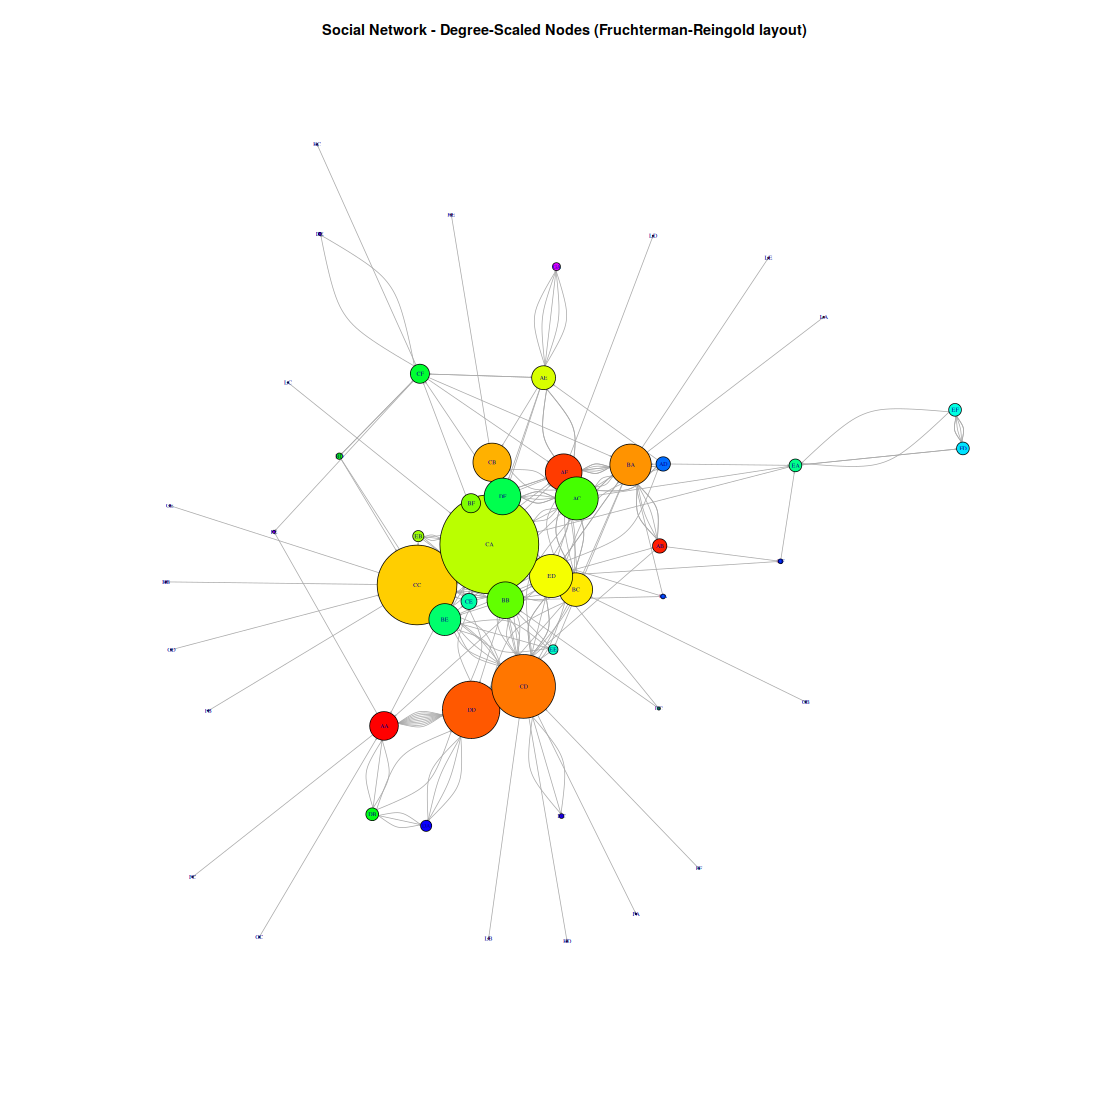

In [ ]:
plot(net,
     vertex.color = rainbow(52),
     vertex.size = V(net)$degree*0.4,
     edge.arrow.size = 0.1,
     layout=layout.fruchterman.reingold,
     main = "Social Network - Degree-Scaled Nodes")

**Observation:** Nodes `CA`, `CC`, `CD`, and `DD` visibly stand out as the largest circles — these are the most connected individuals in the network, forming a dense core, while many peripheral nodes connect only into this core with a single edge.

## Part 5 — Identifying Influential Nodes: Hubs & Authorities (HITS)

The **HITS algorithm** identifies two kinds of importance:
- **Hub score** — a node that points to many other important nodes (a "connector"/"broadcaster")
- **Authority score** — a node that is pointed to by many hubs (a "popular"/"referenced" node)

Warning message:
`hub_score()` was deprecated in igraph 2.0.3.
i Please use `hits_scores()` instead. 
Warning message:
`authority.score()` was deprecated in igraph 2.0.0.
i Please use `hits_scores()` instead. 


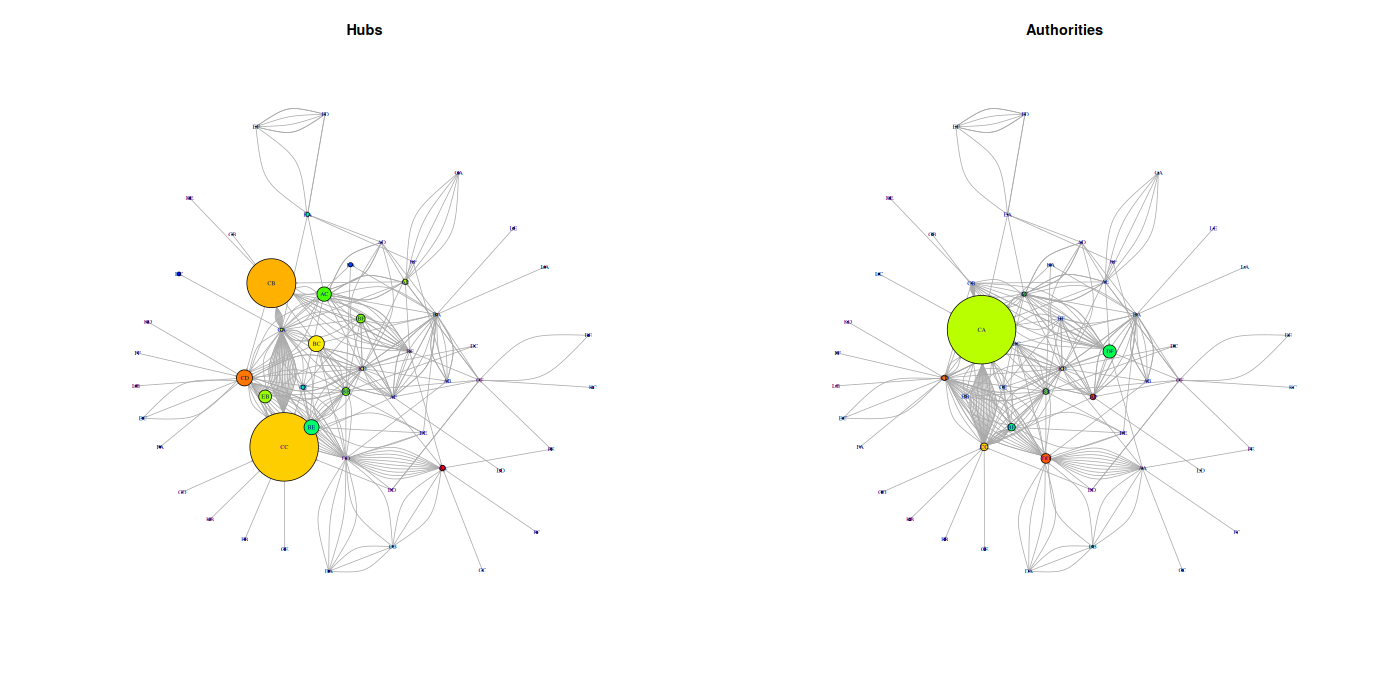

In [ ]:
hs <- hub_score(net)$vector
as <- authority.score(net)$vector

par(mfrow=c(1,2))
set.seed(123)
plot(net, vertex.size=hs*30, main = 'Hubs',
     vertex.color = rainbow(52), edge.arrow.size=0.1,
     layout = layout.kamada.kawai)
plot(net, vertex.size=as*30, main = 'Authorities',
     vertex.color = rainbow(52), edge.arrow.size=0.1,
     layout = layout.kamada.kawai)
par(mfrow=c(1,1))

In [ ]:
top_hubs <- sort(hs, decreasing = TRUE)[1:10]
top_auth <- sort(as, decreasing = TRUE)[1:10]
cat("Top 10 nodes by Hub score:\n"); print(round(top_hubs, 4))
cat("\nTop 10 nodes by Authority score:\n"); print(round(top_auth, 4))
cat("\nTop 10 nodes by raw Degree:\n")
sort(degree(net), decreasing = TRUE)[1:10]

Top 10 nodes by Hub score:
    CC     CB     CD     BC     BE     AC     EB     BF     BB     AA 
1.0000 0.7146 0.2350 0.2322 0.2195 0.2094 0.1870 0.1272 0.1151 0.0804 

Top 10 nodes by Authority score:
    CA     DF     DD     CC     BE     AF     BB     CD     AC     ED 
1.0000 0.1926 0.1410 0.1122 0.1095 0.0838 0.0832 0.0789 0.0626 0.0480 

Top 10 nodes by raw Degree:
CA CC CD DD ED AC BA CB AF BB 
62 50 40 36 27 27 26 24 23 23 


**Interpretation:**
- **`CC`** is the top **hub** (score 1.0) — it initiates the most interactions toward other important nodes.
- **`CA`** is the top **authority** (score 1.0) with the highest raw degree (62) — it is the most-referenced /
  most "popular" individual in the network, receiving interactions from many other nodes.
- `CD` and `DD` appear high in both raw degree and authority score, marking them as consistently central,
  well-connected individuals — likely key influencers or coordinators within this social structure.

## Part 6 — Community Detection

We use **edge-betweenness clustering** (`cluster_edge_betweenness`) to detect natural groupings/communities
within the network — clusters of nodes that interact more densely with each other than with the rest of the
network. Community detection is generally performed on the undirected view of the network.

In [ ]:
net_u <- graph.data.frame(y, directed = FALSE)
cnet <- cluster_edge_betweenness(net_u)

cat("Number of communities detected:", length(cnet), "\n")
cat("Modularity:", round(modularity(cnet), 4), "\n")
sizes(cnet)

Number of communities detected: 26 
Modularity: 0.3514 
Community sizes
Community sizes
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 
 7  4 10  4  1  3  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 


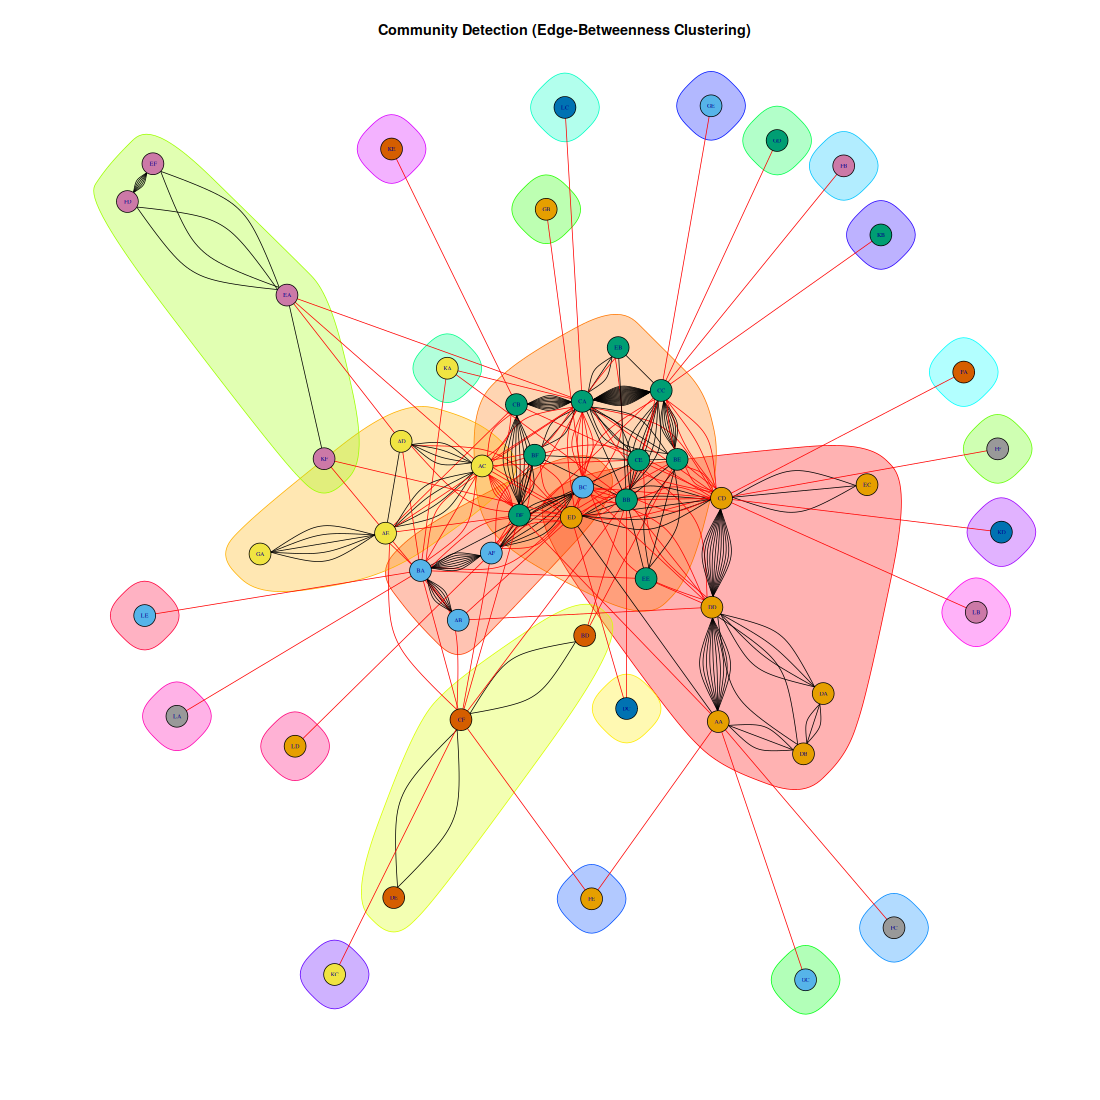

In [ ]:
plot(cnet, net_u, vertex.label.cex = 0.5, vertex.size = 5,
     main = "Community Detection (Edge-Betweenness Clustering)")

**Interpretation:** The algorithm found **26 communities** with a modularity of **0.35**, which indicates a
moderately strong community structure (values above ~0.3 are generally considered meaningful). One large core
community (10 nodes) plus a few medium clusters (4–7 nodes) account for most of the interaction activity, while
17 communities are singleton nodes that interact with the core but not densely enough among themselves to form
a larger group — consistent with the "hub-and-periphery" pattern seen in the visualizations above.

## Part 7 — Summary of Key Results & Conclusion

| Measure | Result |
|---|---|
| Nodes (people) | 52 |
| Edges (interactions) | 290 |
| Top hub | `CC` (score 1.00) |
| Top authority | `CA` (score 1.00, degree 62) |
| Communities detected | 26 (modularity = 0.35) |
| Largest community size | 10 nodes |

### Interpretation
This lab reproduced the Social Network Analysis workflow demonstrated in the reference tutorial using the
`igraph` package in R. The dataset was represented as a directed graph with individuals as nodes and interactions
as edges. Centrality analysis revealed a small set of highly connected individuals (`CA`, `CC`, `CD`, `DD`) who
dominate the network's structure — `CC` acts as the primary *hub* (initiating many important connections) while
`CA` is the primary *authority* (receiving the most incoming connections). Community detection confirmed a
hub-and-periphery structure: one dense core community plus many smaller/singleton groups loosely attached to it.

These results mirror common real-world social network patterns, where a small number of influential nodes
disproportionately shape the flow of interaction across the whole network — directly relevant to applications
such as social media influence analysis, organizational communication mapping, and recommendation systems.
